---
title: Checking Model Assumptions
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

In this study, we fit models to estimate outcomes given input sets of covariates and then interpret the patterns learned by the models. However, their interpretation can be complicated by things like correlated features, which can lead to the models being evaluated on implausible combinations of characteristics or having importance split between multiple features. Another issue might be outliers in the outcome variable, which

In [29]:
# loading up the dataset
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from abbreviations_units import *
catalog = pd.read_hdf('../outputs/data_products/full_dataset_clean.h5')

# Multicollinearity

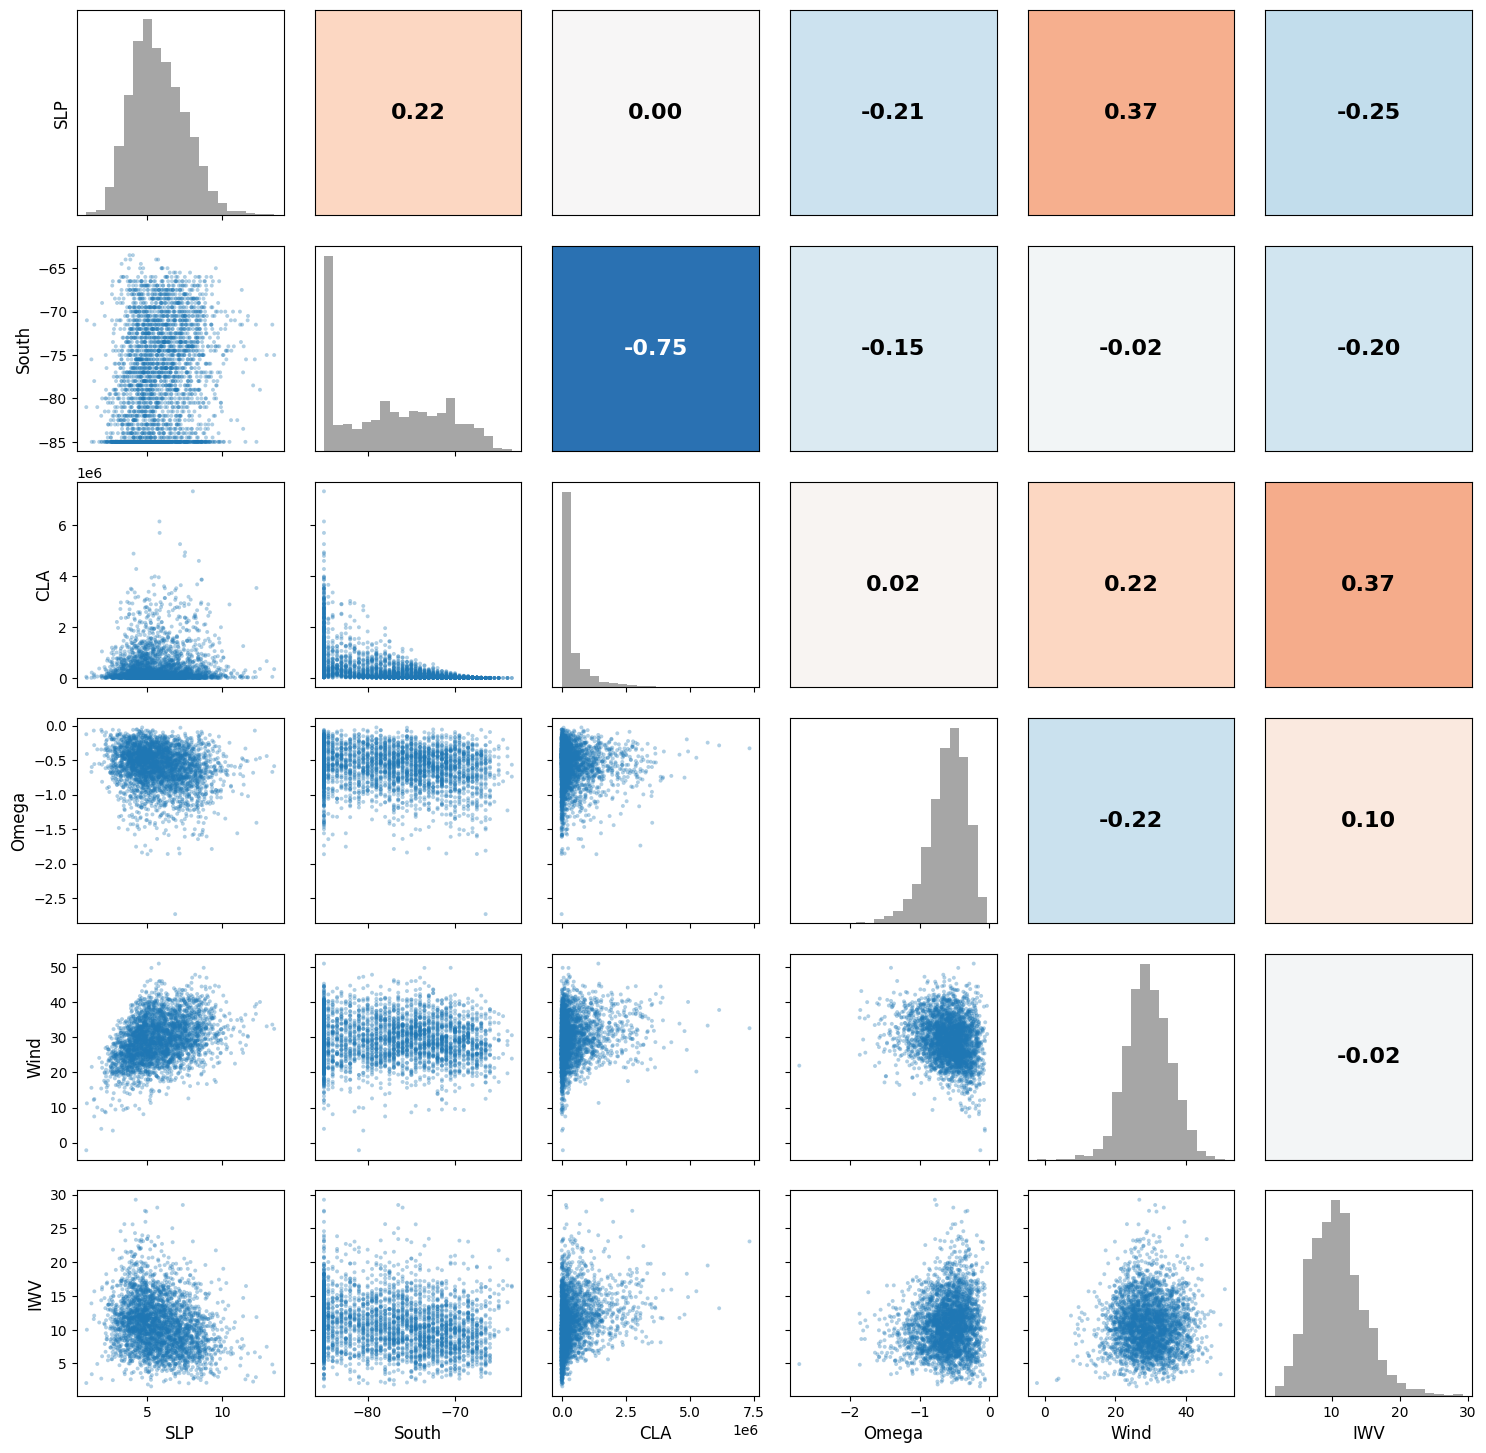

In [19]:
X = catalog[['max_ocean_SLP_gradient',
             'max_south_extent',
             'cumulative_landfalling_area',
             'avg_landfalling_minomega',
             'max_landfalling_v850hPa',
             'max_IWV_ais']]

features = list(X.columns)
n = len(features)
rho, _ = spearmanr(X.values)

cmap = plt.cm.RdBu_r
norm = plt.Normalize(-1, 1)

fig, axs = plt.subplots(n, n, figsize=(3 * n, 3 * n))

for i in range(n):
    for j in range(n):
        ax = axs[i, j]

        if i == j:
            ax.hist(X[features[i]], bins=20, color='gray', alpha=0.7)
            ax.set_yticks([])

        elif i > j:
            ax.scatter(X[features[j]], X[features[i]], s=8, alpha=0.35, edgecolor='none')

        else:
            r = rho[i, j]
            ax.set_facecolor(cmap(norm(r)))
            ax.text(0.5, 0.5, f'{r:.2f}', transform=ax.transAxes,
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color=('white' if abs(r) > 0.5 else 'black'))
            ax.set_xticks([]); ax.set_yticks([])

        # variable names only on the outer edges
        if i == n - 1:
            ax.set_xlabel(ABBV_DICT.get(features[j], features[j]), fontsize=12)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(ABBV_DICT.get(features[i], features[i]), fontsize=12)
        else:
            ax.set_yticklabels([])

fig.subplots_adjust(wspace=0.15, hspace=0.15)
plt.savefig('../outputs/plots/collinearity_triangle.png', dpi=300, bbox_inches='tight')
plt.show()

Assessing collinearity, we see a few relationships jump out: for example, it seems like cumulative landfalling area and maximum southward extent are both fairly negatively correlated, meaning that as storms travel further south, they tend to spend more cumulative time and space over the AIS. So, care should be expressed in interpreting these relationships. The next two correlations are much more modest, between cumulative landfalling area and IWV and wind speed and landfalling sea-level pressure. Every other correlation is much weaker. In conclusion, because of the correlation between CLA and South, care should be expressed when comparing these two variables in feature rankings, etc. However, since these are both more geographic characteristics, rankings and comparisons between the two are less of interest, so this should not be a big deal. Furthermore, the remaining correlations appear small enough, and the scatter plots are sufficiently noisy, so that we can conclude pairwise collinearity is not a significant challenge.

# Outliers

Let's first plot histograms of each variable, characteristic and outcome, to assess outliers.

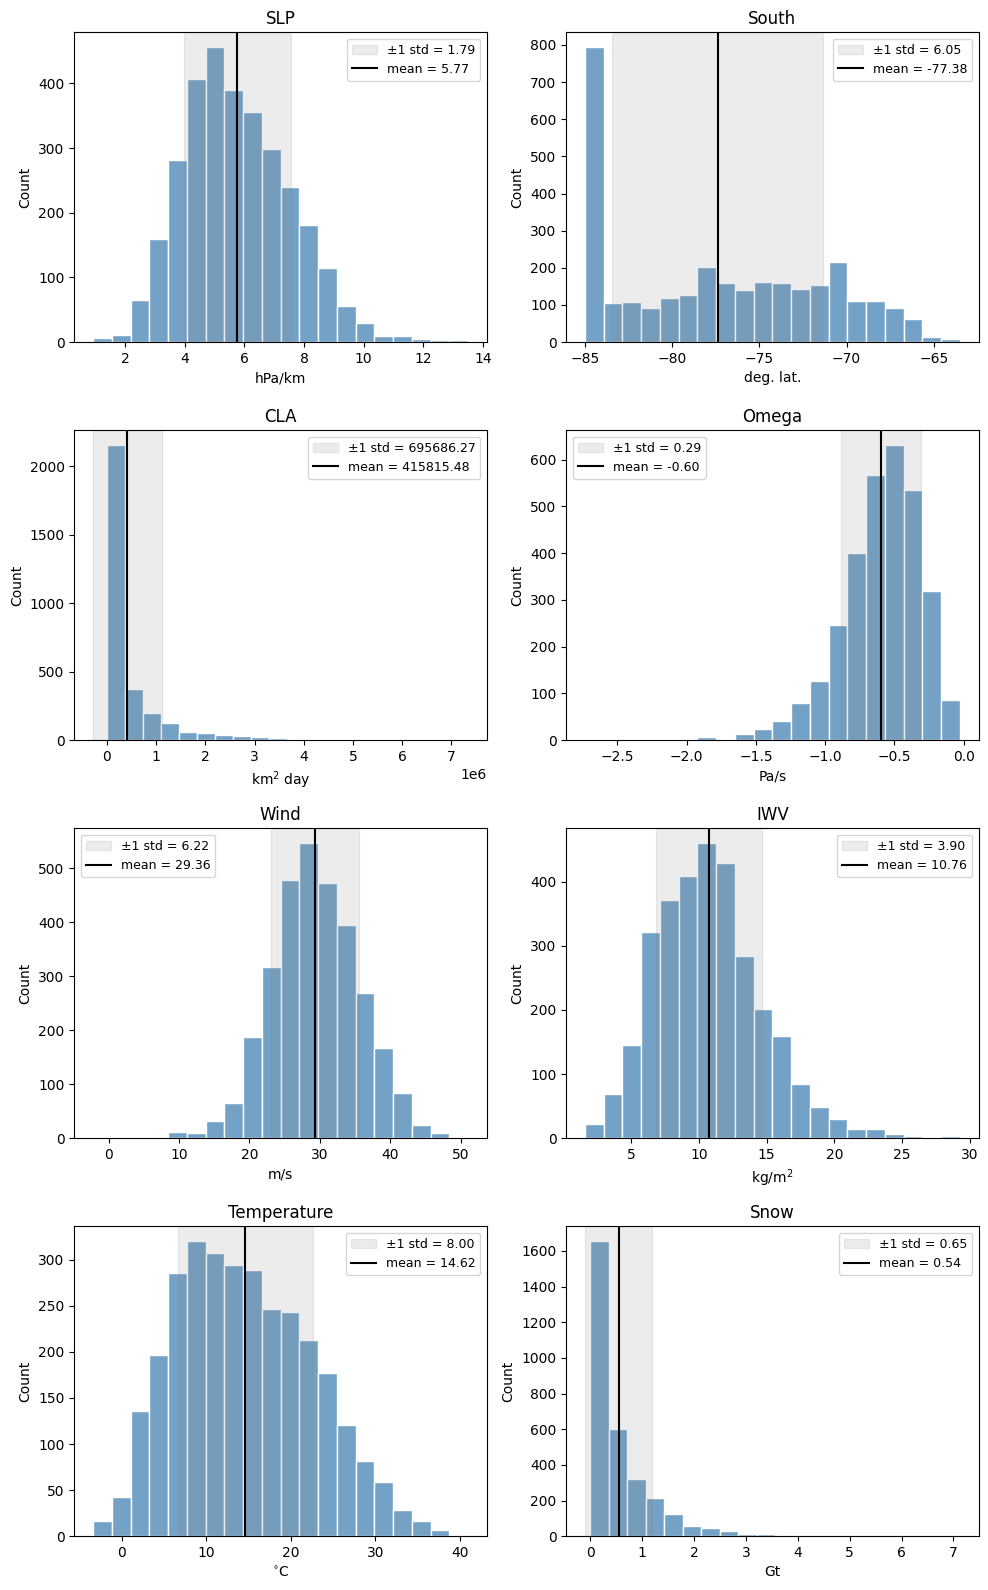

In [22]:
# pick the variables to plot (numeric columns by default; or pass your own list)
variables = ['max_ocean_SLP_gradient',
             'max_south_extent',
             'cumulative_landfalling_area', 
             'avg_landfalling_minomega',
             'max_landfalling_v850hPa',
             'max_IWV_ais',
             'max_T2M_anomaly_ais',
             'cumulative_snowfall_ais']

n = len(variables)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, var in zip(axes, variables):
    data = catalog[var].dropna()
    mu = data.mean()
    sigma = data.std()

    sns.histplot(data, bins=20, ax=ax, color='steelblue', edgecolor='white')

    ax.axvspan(mu - sigma, mu + sigma, color='gray', alpha=0.15,
               label=f'±1 std = {sigma:.2f}')
    ax.axvline(mu, color='black', linewidth=1.5,
               label=f'mean = {mu:.2f}')

    ax.set_title(ABBV_DICT[var])
    ax.set_xlabel(UNITS_DICT[var])
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# hide any leftover empty axes
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()

plt.savefig('../outputs/plots/univariate_histograms.png', dpi=300, bbox_inches='tight')

Among characteristics, it seems like the only variables for which there are significant outliers are Omega (with a very low outlier), CLA (with a very high outlier), and Wind (with a very low outlier). Among the outcome variables, there are no crazy temperature outliers, but there sure are some crazy snowfall outliers. For the GBEX model, the presence of outliers in the outcome variable should be tolerable, since extreme values in the outcome variable are exactly what these kinds of extreme procedures seek to target. However, for the XGBoost fit, since the trees are grown to minimize squared error loss, these outliers can have a significant effect on how the trees are grown, and thus on the interpretation of the resulting model.

We noticed that CLA and cumulative snowfall are highly linearly correlated, so we first fit a linear regression of snowfall on CLA, and used the residuals as the outcome to train XGBoost. Let's compare the what the outcome distributions look like in the training set for both the raw snowfall values and the residual values, to see how the state of the outliers may have changed.

In [30]:
with open('../auxiliary_files/hyperparam_dictionaries/xgboost/best_snow_xgb.json', 'r') as file:
        best_snow = json.load(file)

In [31]:
# creating the dictionary of hyperparameters for training

hyperparam_dict = {}
hyperparam_dict['gamma'] = float(best_snow['gamma'])
hyperparam_dict['max_depth'] = int(best_snow['max_depth'])
hyperparam_dict['reg_lambda'] = float(best_snow['reg_lambda'])
hyperparam_dict['min_child_weight'] = float(best_snow['min_child_weight'])
hyperparam_dict['subsample_frac'] = float(best_snow['subsample_frac'])
hyperparam_dict['eta'] = float(best_snow['eta'])
hyperparam_dict['booster'] = 'gbtree'
hyperparam_dict['tree_method'] = 'exact'
hyperparam_dict['objective'] = 'reg:squarederror'
hyperparam_dict['eval_metric'] = 'rmse'
num_boost = int(best_snow['num_boost'])
shrinkage_factor = best_snow['shrinkage_factor']

In [32]:
# creating training and test data objects

train_data = pd.read_csv('../outputs/data_products/train.csv', index_col='Label')
test_data = pd.read_csv('../outputs/data_products/test.csv', index_col='Label')
y_col = 'cumulative_snowfall_ais'
x_cols = ['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 
          'avg_landfalling_minomega', 'max_IWV_ais', 
          'cumulative_landfalling_area', 'max_south_extent']

X_train = train_data[x_cols]
y_train = train_data[y_col]
X_test = test_data[x_cols]
y_test = test_data[y_col]
y_train_centered = y_train - y_train.mean()
y_test_centered = y_test - y_train.mean()

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

In [33]:
# training linear regression on CLA to obtain residuals

linreg = LinearRegression(fit_intercept=False)
x_cla_mean = X_train['cumulative_landfalling_area'].mean()
x_cla_centered = X_train['cumulative_landfalling_area'] - x_cla_mean
linear_fit = linreg.fit(X=pd.DataFrame(x_cla_centered), y=y_train_centered)
resid = y_train_centered - linear_fit.predict(pd.DataFrame(x_cla_centered))

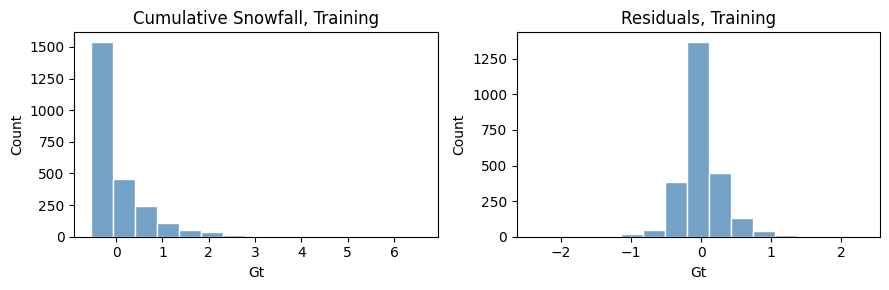

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3))
sns.histplot(y_train_centered, bins=15, ax=axs[0], color='steelblue', edgecolor='white')
sns.histplot(resid, bins=15, ax=axs[1], color='steelblue', edgecolor='white')
axs[0].set_xlabel('Gt')
axs[0].set_title('Cumulative Snowfall, Training')
axs[1].set_xlabel('Gt')
axs[1].set_title('Residuals, Training')
plt.tight_layout()
plt.savefig('../outputs/plots/snowfall_outliers.png', dpi=300, bbox_inches='tight')

Though there still are some outliers in the residuals, they are more symmetrically spread, and degree to which the outliers are extreme, noted by the deviation from the mean, is much smaller. This is of course still something to keep in mind, but it overall seems like this preprocessing has reduced the influence of the single large outlier found in the training set.